# ABAGEN Microarray Genetic Data for Schaefer200 in fsaverage 164k density by Tau baseline symptomatic v control 
## Author: Diana A. Hobbs
### Date: March 2026

In [1]:
from pyforest import *

In [2]:
from netneurotools import datasets as nntdata
import neuromaps.images, nibabel as nib

schaefer = nntdata.fetch_schaefer2018('fsaverage')['200Parcels7Networks']
print(schaefer)  # annot files lh, rh

# load as gifti & save paths (abagen requires paths)
schaefer_gii = neuromaps.images.annot_to_gifti(schaefer)
nib.save(schaefer_gii[0], "/Users/hobbsd/nnt-data/atl-schaefer2018/fsaverage/schaefer200_lh.label.gii") # path to where & name you want to save schaefer_gii[0]
nib.save(schaefer_gii[1], "/Users/hobbsd/nnt-data/atl-schaefer2018/fsaverage/schaefer200_rh.label.gii")

Surface(lh='/Users/hobbsd/nnt-data/atl-schaefer2018/fsaverage/atl-Schaefer2018_space-fsaverage_hemi-L_desc-200Parcels7Networks_deterministic.annot', rh='/Users/hobbsd/nnt-data/atl-schaefer2018/fsaverage/atl-Schaefer2018_space-fsaverage_hemi-R_desc-200Parcels7Networks_deterministic.annot')


In [3]:
from neuromaps.datasets import fetch_fsaverage

# get space
fsaverage = fetch_fsaverage(density='164k')
print(fsaverage['pial']) # print path for next cell 

Surface(L=PosixPath('/Users/hobbsd/neuromaps-data/atlases/fsaverage/tpl-fsaverage_den-164k_hemi-L_pial.surf.gii'), R=PosixPath('/Users/hobbsd/neuromaps-data/atlases/fsaverage/tpl-fsaverage_den-164k_hemi-R_pial.surf.gii'))


In [21]:
from abagen import get_expression_data
from abagen.images import check_atlas

sch_lh = "/Users/hobbsd/nnt-data/atl-schaefer2018/fsaverage/schaefer200_lh.label.gii" # path where you saved schaefer_gii[0]
sch_rh = "/Users/hobbsd/nnt-data/atl-schaefer2018/fsaverage/schaefer200_rh.label.gii"
fs_lh = "/Users/hobbsd/neuromaps-data/atlases/fsaverage/tpl-fsaverage_den-164k_hemi-L_pial.surf.gii" # path from above cell 
fs_rh = "/Users/hobbsd/neuromaps-data/atlases/fsaverage/tpl-fsaverage_den-164k_hemi-R_pial.surf.gii"

atlas_obj  = check_atlas([sch_lh, sch_rh], geometry=[fs_lh, fs_rh], space="fsaverage")

expression = get_expression_data(
    atlas_obj,
    lr_mirror='bidirectional', # all of these here and below are optional
    missing='centroids',
    probe_selection='diff_stability',
    sample_norm='srs',
    gene_norm='srs',
    norm_matched=True,
)

/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/utils.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  info = info.append(
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/utils.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  info = info.append(
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/surfaces.py:133: RuntimeWarning: invalid value encountered in divide
  w = (np.sum((A - B) * (V - B), axis=0, keepdims=True)
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
/opt/anaconda3/envs/brainenv/lib/python3.9/site-pac

In [22]:
expression # you should have n=~15k genes (cols) by n=200 schaefer parcellations (rows)

gene_symbol,A1BG,A1BG-AS1,A2M,A2ML1,A3GALT2,A4GALT,AAAS,AACS,AADACL3,AADAT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3
label,,,,,,,,,,,,,,,,,,,,,
1,0.415346,0.479017,0.470681,0.618652,0.564935,0.424049,0.448760,0.686617,0.649394,0.479777,...,0.495973,0.481318,0.438184,0.485097,0.580970,0.524648,0.611983,0.536163,0.695030,0.425067
2,0.363002,0.341188,0.513425,0.566501,0.472736,0.359974,0.642107,0.433885,0.505009,0.588260,...,0.506723,0.432217,0.490104,0.540985,0.531780,0.525900,0.440906,0.678568,0.752978,0.492264
3,0.515889,0.366148,0.596697,0.588313,0.518101,0.551474,0.554471,0.388027,0.503257,0.425835,...,0.423494,0.490441,0.326532,0.546142,0.482097,0.583487,0.350143,0.554551,0.567006,0.546735
4,0.183828,0.355546,0.469512,0.570886,0.589590,0.531784,0.676804,0.573488,0.562918,0.510099,...,0.630728,0.550914,0.505535,0.614798,0.538718,0.516868,0.607908,0.823344,0.837826,0.311693
5,0.295845,0.317779,0.511026,0.429091,0.476845,0.522423,0.733568,0.456798,0.530676,0.472650,...,0.501035,0.487780,0.418424,0.538261,0.415247,0.487978,0.483249,0.866763,0.726793,0.370475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,0.376748,0.497998,0.428272,0.591640,0.577329,0.363965,0.489937,0.713362,0.595055,0.516034,...,0.451972,0.271714,0.411813,0.531649,0.663890,0.412189,0.722732,0.372234,0.492262,0.470334
197,0.640260,0.526387,0.463116,0.350522,0.432000,0.625197,0.593116,0.551969,0.332461,0.446605,...,0.559222,0.581251,0.483287,0.593495,0.360400,0.417864,0.357218,0.521753,0.417545,0.549193
198,0.506584,0.457634,0.642332,0.631412,0.584653,0.537052,0.585220,0.576985,0.577147,0.494455,...,0.566093,0.419652,0.340364,0.525318,0.465997,0.568196,0.453671,0.522755,0.704256,0.491055


In [23]:
# Import ADRC information in Schaefer200 space
tau_data = pd.read_csv('/Users/hobbsd/Downloads/regional_tau_data_schaefer7_,200_220822.csv', sep=",")
tau_summary = tau_data[['ROI.Label','region','hemi','baseline_taudif_symptomatic_control']]
tau_diff = tau_summary['baseline_taudif_symptomatic_control'].to_numpy()

<IPython.core.display.Javascript object>

In [24]:
from neuromaps.parcellate import Parcellater
from neuromaps.nulls import alexander_bloch

rotated_tau_diff = alexander_bloch(data=tau_diff, atlas='fsaverage', density='164k', n_perm=1000, seed=42, parcellation=schaefer_gii)
print(rotated_tau_diff.shape)

(200, 1000)


In [42]:
from neuromaps.stats import compare_images

corr, pval = compare_images(expression["MAPT"], tau_diff, metric='spearmanr', nulls=rotated_tau_diff)
print(f'r = {corr:.3f}, p = {pval:.3f}')

r = 0.349, p = 0.296


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

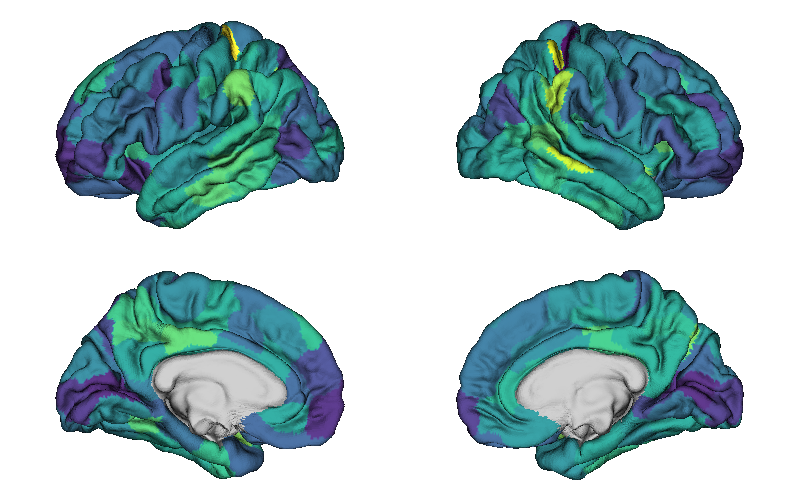

In [43]:
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting.surface_plotting import plot_hemispheres
from brainspace.utils.parcellation import map_to_labels

lh_surf = read_surface(fs_lh)
rh_surf = read_surface(fs_rh)

# Extract labels
lh_labels = schaefer_gii[0].darrays[0].data
rh_labels = schaefer_gii[1].darrays[0].data
labels = np.concatenate([lh_labels, rh_labels])


vertexwise = map_to_labels(
    expression["MAPT"],
    labels,
    mask=labels != 0,
    fill=np.nan,
)
plot_hemispheres(
    lh_surf, rh_surf,
    vertexwise,
    color_bar=False,
    embed_nb=True,
    size=(800, 500),
    zoom=1.5,
    nan_color=(0.7, 0.7, 0.7, 1),
    layout_style='grid',
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

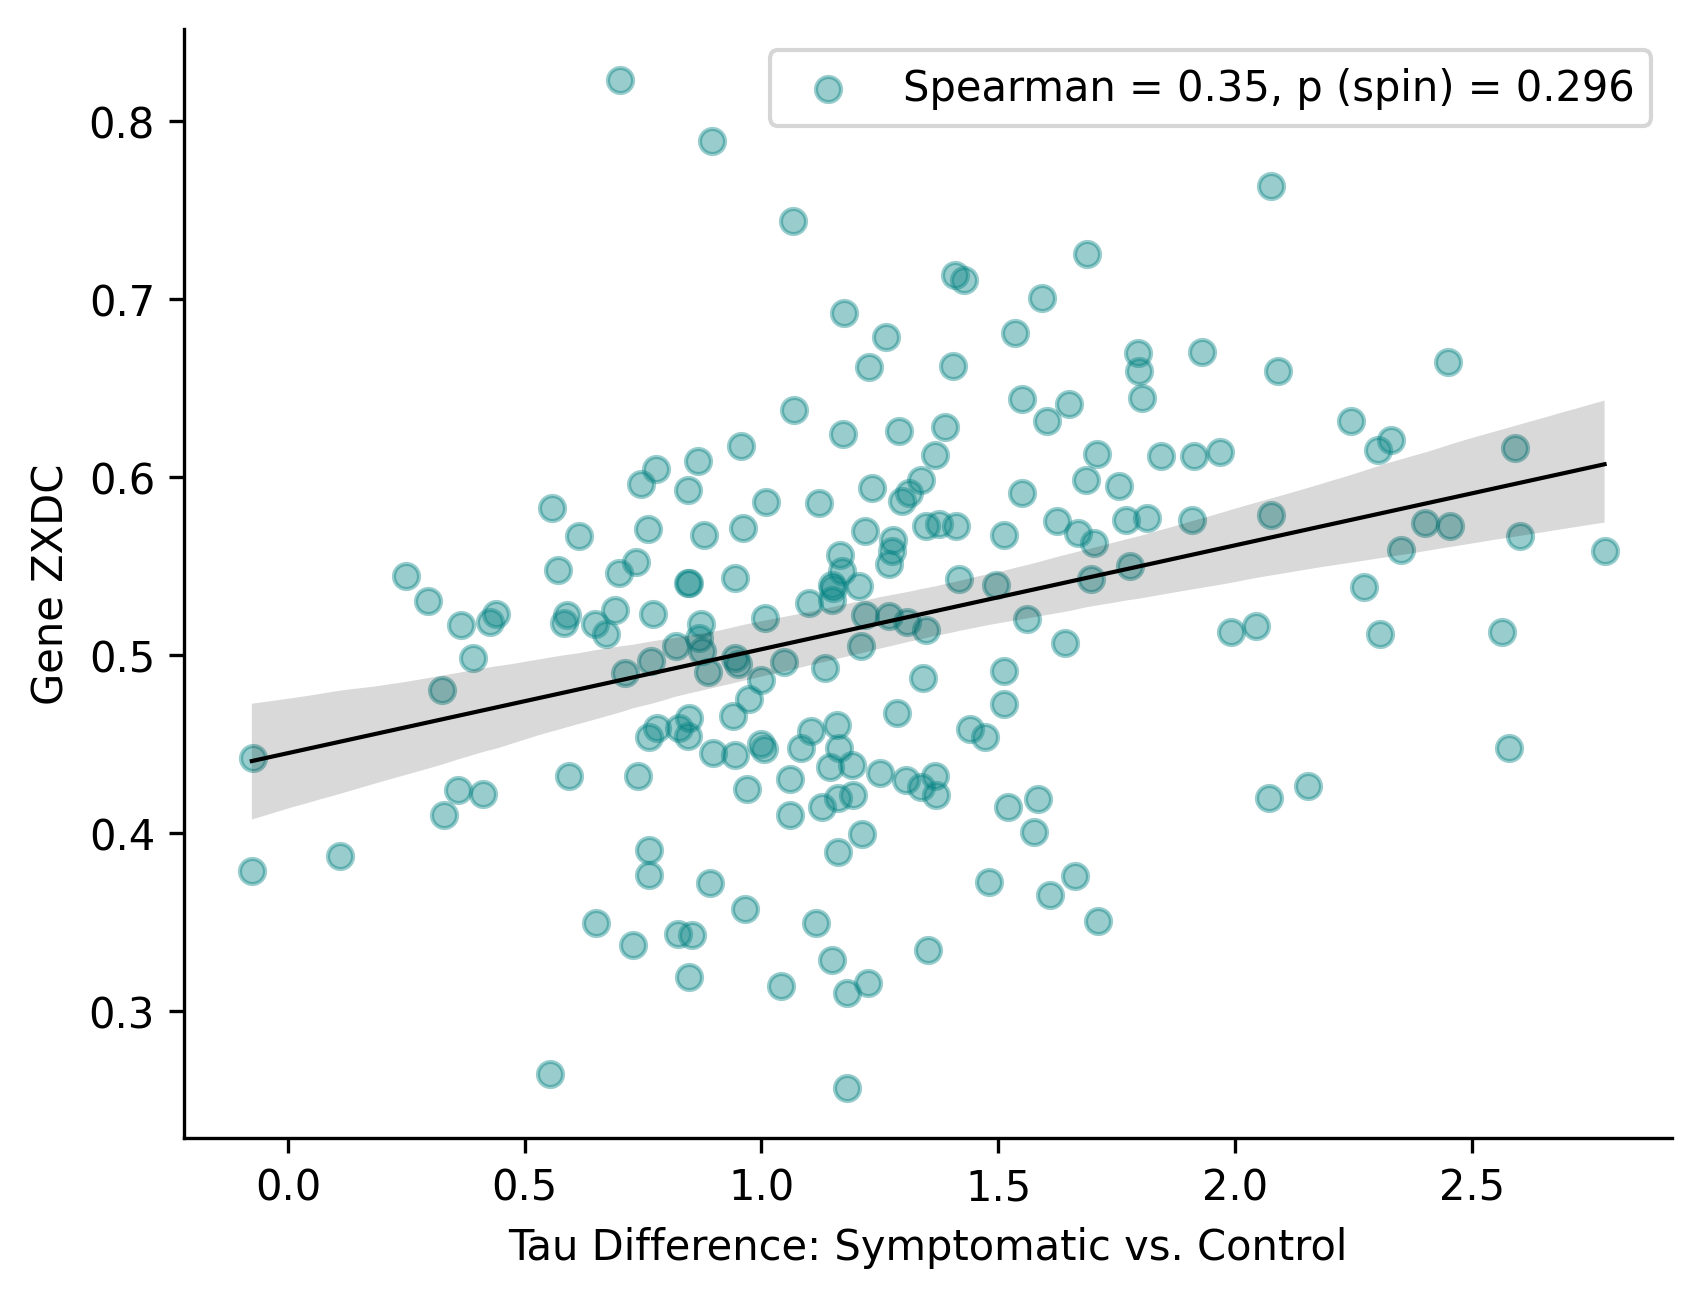

In [44]:
import seaborn as sns
#Spearman plot 
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
from scipy.stats import spearmanr
df = pd.DataFrame({"x": tau_diff, "y": expression["MAPT"]})
r, pvalue = spearmanr(df['x'], df['y'])
import seaborn as sns
sns.regplot(data=df, x="x", y="y", 
            label=f'Spearman = {r:.2f}, p (spin) = {pval:.3f}',
            line_kws={"color": "black", "lw":1},
            scatter_kws={"color": "teal","alpha":0.4}).set(xlabel="Tau Difference: Symptomatic vs. Control", 
                                                           ylabel="Gene ZXDC")
plt.legend()
sns.despine()


In [45]:
corr, pval = compare_images(
    expression["MAPT"].values,
    tau_diff,
    metric='spearmanr',
    nulls=rotated_tau_diff
)
print(f'r = {corr:.3f}, p (spin) = {pval:.3f}')

r = 0.349, p (spin) = 0.296


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

0


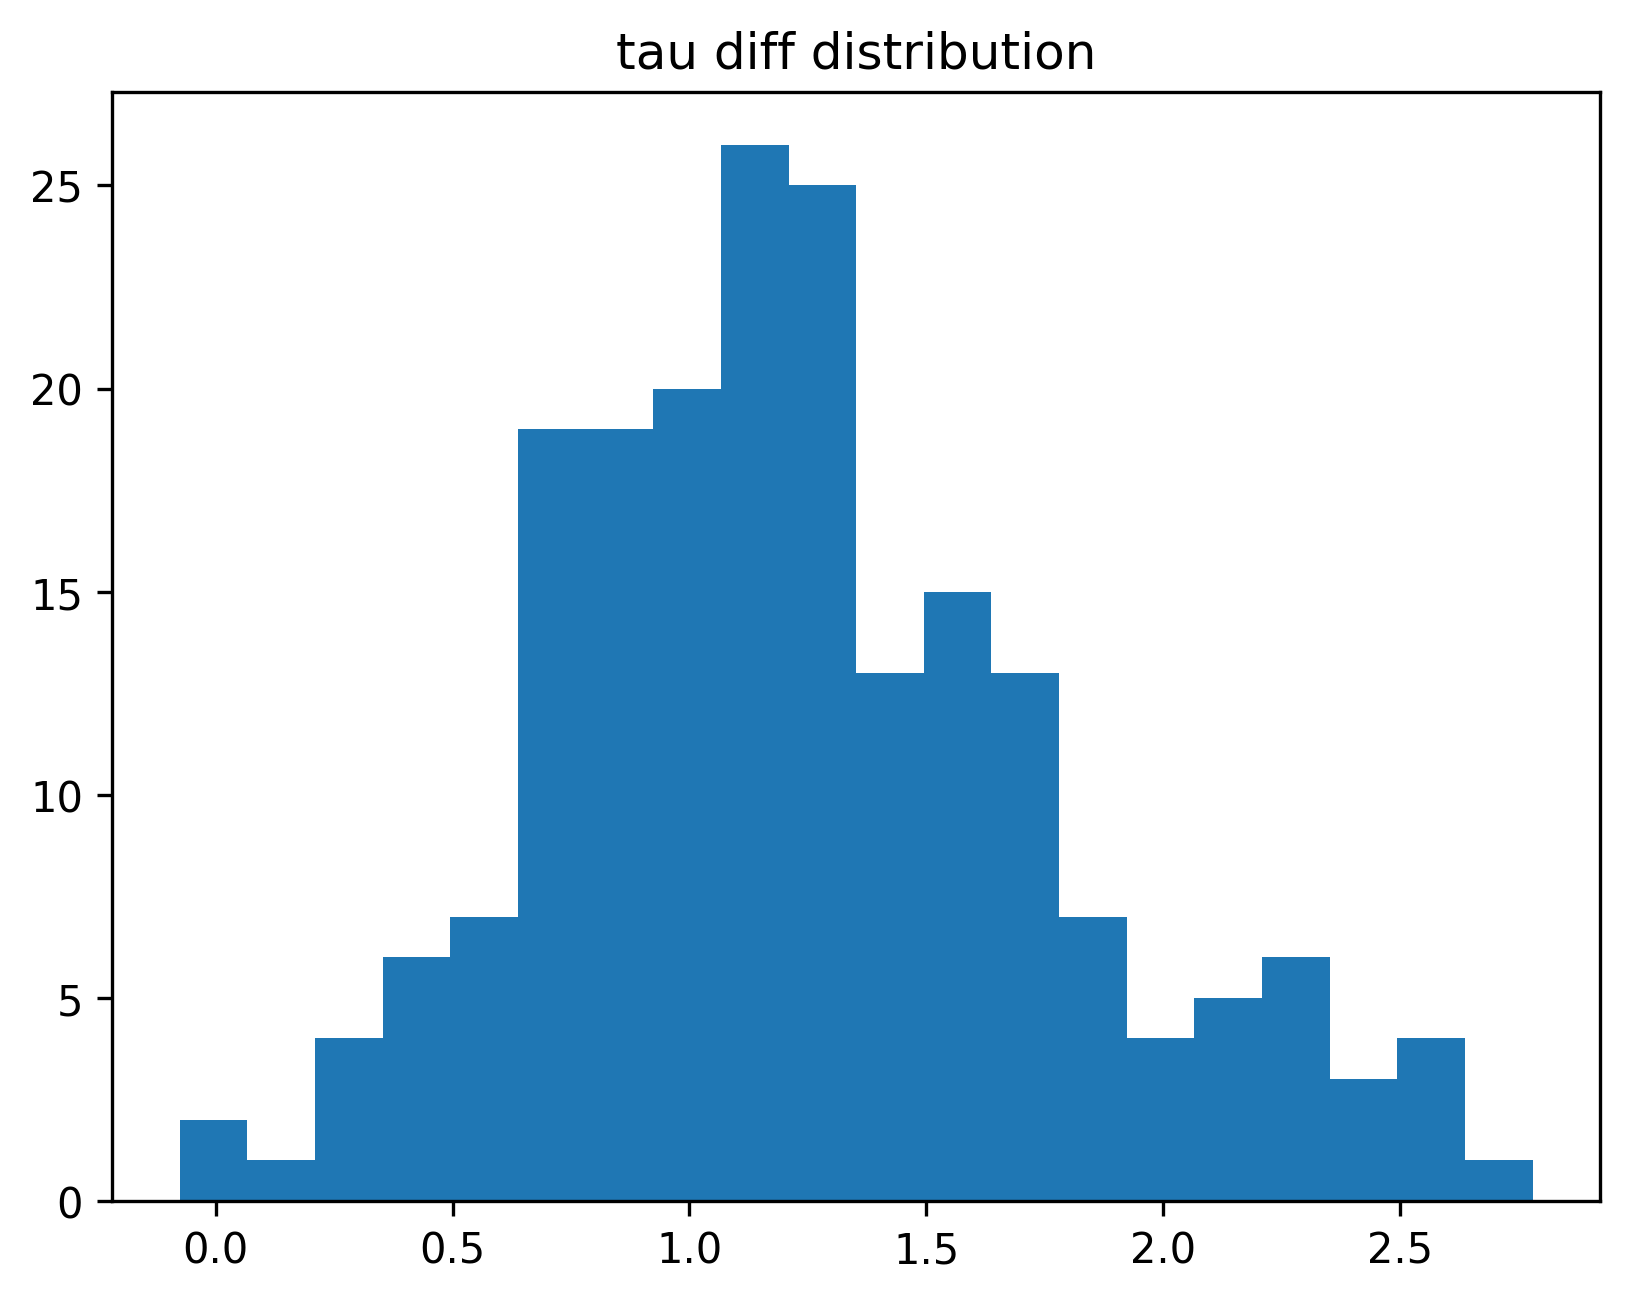

Index(['ROI.Label', 'region', 'R', 'A', 'S', 'hemi', 'label', 'n_positive_tau',
       'mean_positive_suvr', 'total_tau_average', 'baseline_tau_average',
       'baseline_tau_control', 'baseline_tau_preclinical',
       'baseline_tau_symptomatic', 'baseline_taudif_symptomatic_control',
       'baseline_taudif_preclinical_control'],
      dtype='object')


In [47]:
# 1. Any NaNs in tau_diff?
print(np.sum(np.isnan(tau_diff)))

# 2. Distribution look sensible?
import matplotlib.pyplot as plt
plt.hist(tau_diff, bins=20)
plt.title("tau diff distribution")
plt.show()

# 3. Try with raw tau instead of the difference score
# if your CSV has it
print(tau_data.columns)

In [48]:
# Nulls should be (200, 1000)
print(rotated_tau_diff.shape)

# And should have variance
print(rotated_tau_diff.std(axis=1).mean())  # should not be ~0


(200, 1000)
0.5626039831189039


In [49]:
# Regenerate nulls for the new measure
tau_absolute = tau_data['baseline_tau_symptomatic'].to_numpy()

rotated_absolute = alexander_bloch(
    data=tau_absolute,
    atlas='fsaverage',
    density='164k',
    n_perm=1000,
    seed=42,
    parcellation=schaefer_gii
)

corr, pval = compare_images(
    expression["MAPT"].values,
    tau_absolute,
    metric='spearmanr',
    nulls=rotated_absolute
)
print(f'r = {corr:.3f}, p (spin) = {pval:.3f}')

r = 0.338, p (spin) = 0.363


In [50]:
print(rotated_absolute.shape)          # should be (200, 1000)
print(rotated_absolute.std(axis=1).mean())  # should be > 0
print(np.isnan(rotated_absolute).sum())     # should be 0

(200, 1000)
0.1414436067977853


<IPython.core.display.Javascript object>

0


In [51]:
print(expression["MAPT"].describe())
# expect: positive values, decent variance across 200 parcels

count    200.000000
mean       0.517513
std        0.102359
min        0.256904
25%        0.444577
50%        0.521596
75%        0.579894
max        0.823184
Name: MAPT, dtype: float64


In [52]:
# Rerun expression without mirroring
atlas_obj  = check_atlas([sch_lh, sch_rh], geometry=[fs_lh, fs_rh], space="fsaverage")
expression_nomirror = get_expression_data(
    atlas_obj,
    missing='centroids',
    probe_selection='diff_stability',
    sample_norm='srs',
    gene_norm='srs',
    norm_matched=True,
    # no lr_mirror
)

corr, pval = compare_images(
    expression_nomirror["MAPT"].values,
    tau_absolute,
    metric='spearmanr',
    nulls=rotated_absolute
)
print(f'r = {corr:.3f}, p (spin) = {pval:.3f}')

/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/utils.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  info = info.append(
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/utils.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  info = info.append(
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/surfaces.py:133: RuntimeWarning: invalid value encountered in divide
  w = (np.sum((A - B) * (V - B), axis=0, keepdims=True)
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
/opt/anaconda3/envs/brainenv/lib/python3.9/site-pac

r = 0.228, p (spin) = 0.598


<IPython.core.display.Javascript object>

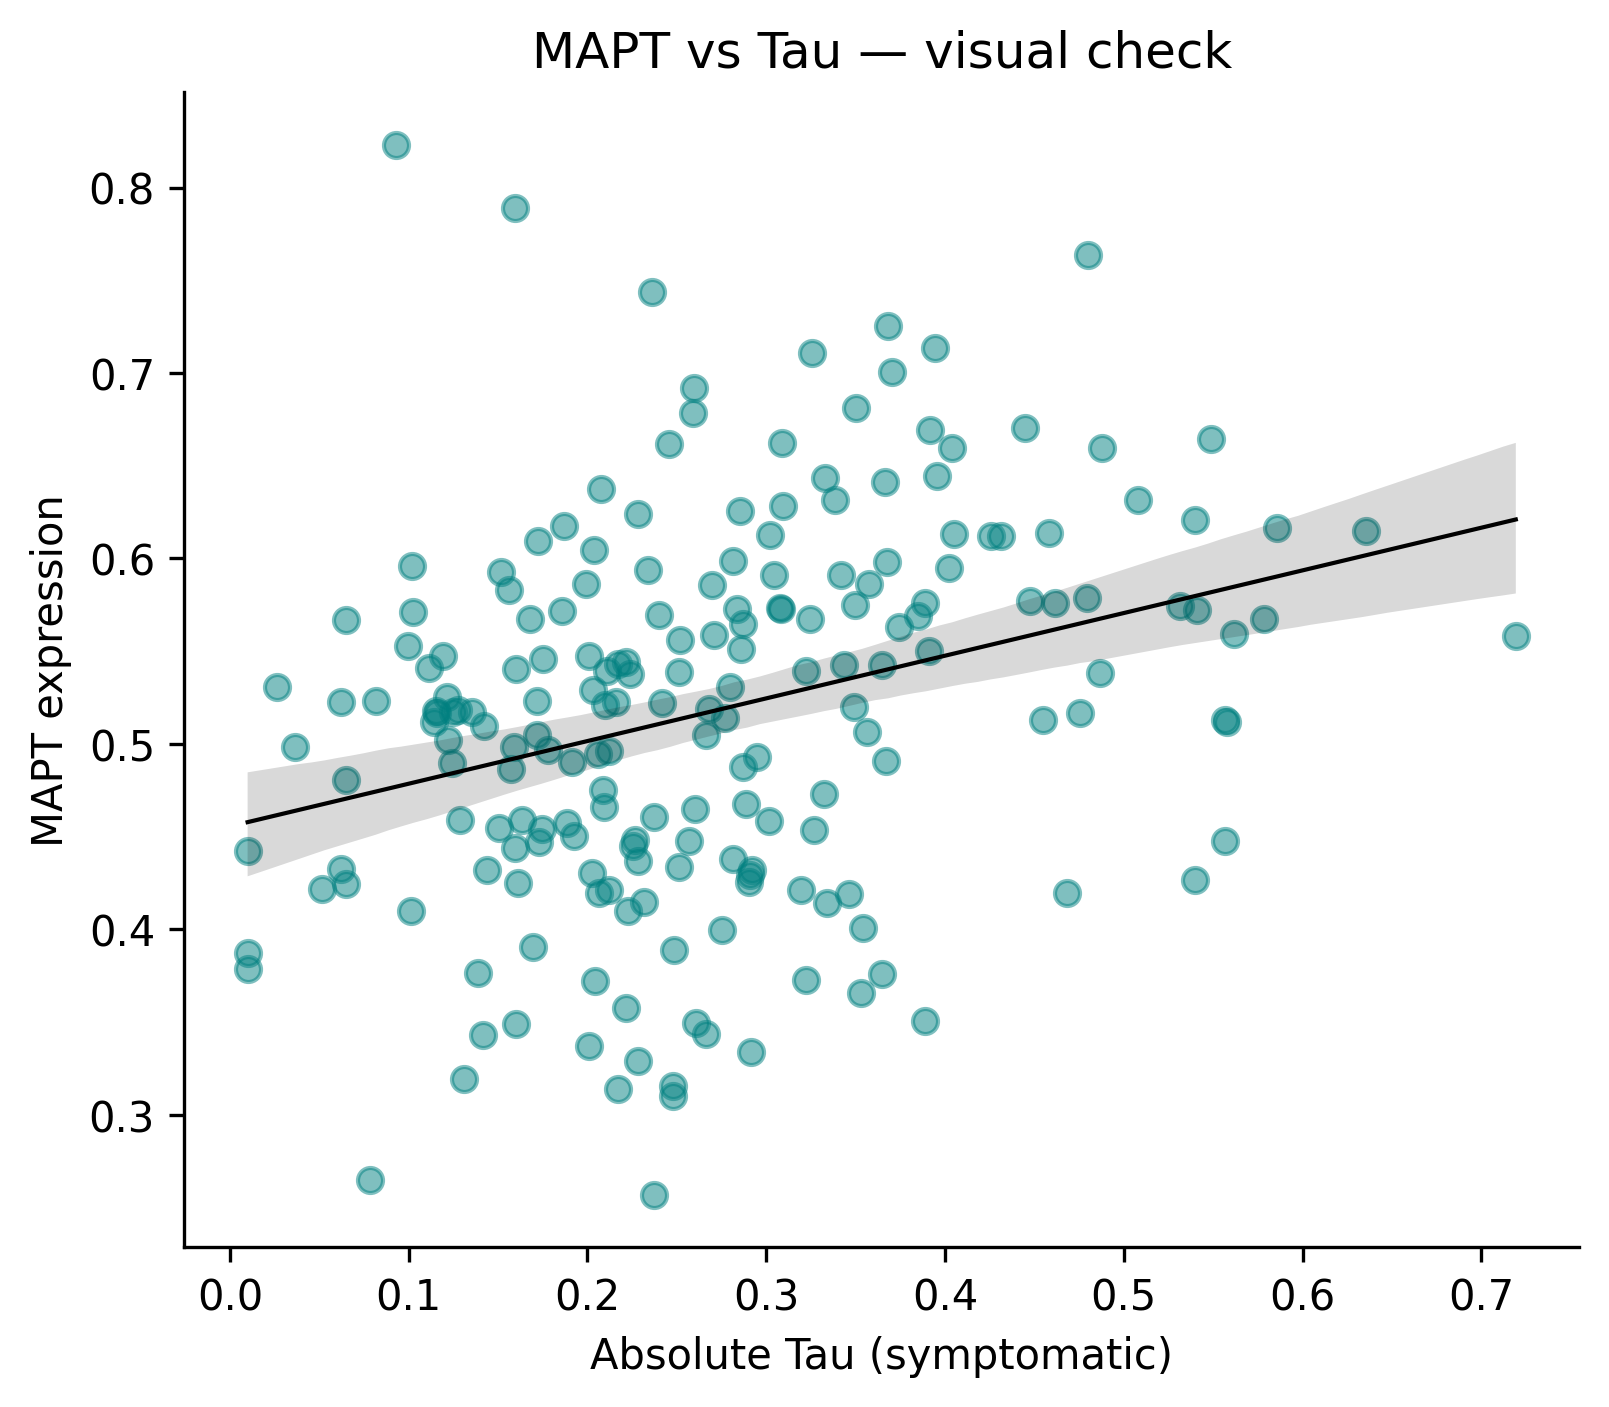

         MAPT       tau                          region
163  0.558470  0.719253  7Networks_RH_Limbic_TempPole_3
56   0.615074  0.635628  7Networks_LH_Limbic_TempPole_1
162  0.616414  0.585774  7Networks_RH_Limbic_TempPole_2
57   0.567145  0.578334  7Networks_LH_Limbic_TempPole_2
134  0.559132  0.561815    7Networks_RH_DorsAttn_Post_1
161  0.512047  0.557657  7Networks_RH_Limbic_TempPole_1
100  0.513045  0.556605              7Networks_RH_Vis_1
99   0.447843  0.556448      7Networks_LH_Default_PHC_1
74   0.664459  0.548562     7Networks_LH_Default_Temp_2
185  0.572329  0.541021     7Networks_RH_Default_Temp_2
         MAPT       tau                                region
26   0.823184  0.092781                7Networks_LH_SomMot_13
127  0.788829  0.159568                7Networks_RH_SomMot_13
187  0.763710  0.480231           7Networks_RH_Default_Temp_4
164  0.743754  0.236232               7Networks_RH_Cont_Par_1
32   0.725213  0.368097          7Networks_LH_DorsAttn_Post_3
151  0.71353

In [53]:
# Plot MAPT vs absolute tau directly
df_check = pd.DataFrame({
    "MAPT": expression["MAPT"].values,
    "tau": tau_absolute,
    "region": tau_data['region'].values
})

plt.figure(figsize=(6,5))
sns.regplot(data=df_check, x="tau", y="MAPT",
            scatter_kws={"alpha":0.5, "color":"teal"},
            line_kws={"color":"black", "lw":1})
plt.xlabel("Absolute Tau (symptomatic)")
plt.ylabel("MAPT expression")
plt.title("MAPT vs Tau — visual check")
sns.despine()
plt.show()

# Also print a few regions to eyeball if they make sense
# MAPT should be high in temporal/limbic regions where tau is high
print(df_check.sort_values("tau", ascending=False).head(10))
print(df_check.sort_values("MAPT", ascending=False).head(10))

In [54]:
atlas_obj = check_atlas([sch_lh, sch_rh], geometry=[fs_lh, fs_rh], space="fsaverage")

expression_raw = get_expression_data(
    atlas_obj,
    lr_mirror='bidirectional',
    missing='centroids',
    probe_selection='diff_stability',
    # no sample_norm, gene_norm, norm_matched
)

df_check = pd.DataFrame({
    "MAPT": expression_raw["MAPT"].values,
    "tau": tau_absolute,
    "region": tau_data['region'].values
})

print(df_check.sort_values("MAPT", ascending=False).head(10))

corr, pval = compare_images(
    expression_raw["MAPT"].values,
    tau_absolute,
    metric='spearmanr',
    nulls=rotated_absolute
)
print(f'r = {corr:.3f}, p (spin) = {pval:.3f}')

/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/utils.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  info = info.append(
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/utils.py:180: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  info = info.append(
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/surfaces.py:133: RuntimeWarning: invalid value encountered in divide
  w = (np.sum((A - B) * (V - B), axis=0, keepdims=True)
/opt/anaconda3/envs/brainenv/lib/python3.9/site-packages/abagen/probes_.py:757: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  micro = micro.set_axis(symbols, axis=1, inplace=False)
/opt/anaconda3/envs/brainenv/lib/python3.9/site-pac

<IPython.core.display.Javascript object>

         MAPT       tau                                region
26   0.823184  0.092781                7Networks_LH_SomMot_13
127  0.788829  0.159568                7Networks_RH_SomMot_13
187  0.763710  0.480231           7Networks_RH_Default_Temp_4
164  0.743754  0.236232               7Networks_RH_Cont_Par_1
32   0.725213  0.368097          7Networks_LH_DorsAttn_Post_3
151  0.713530  0.394222  7Networks_RH_SalVentAttn_FrOperIns_1
59   0.710733  0.325818        7Networks_LH_Limbic_TempPole_4
176  0.700392  0.370164              7Networks_RH_Cont_pCun_1
45   0.692111  0.259687    7Networks_LH_SalVentAttn_ParOper_3
165  0.681129  0.350283               7Networks_RH_Cont_Par_2
r = 0.338, p (spin) = 0.363


In [55]:
# What does abagen think parcel 26 is?
print(expression.index[25])  # label 26

# What does your CSV say parcel 26 is?  
print(tau_data.loc[tau_data['ROI.Label'] == 26, 'region'].values)

# Print the full aligned table to eyeball it
df_check['label'] = expression.index.values
df_check_sorted = df_check.sort_values('label')
print(df_check_sorted[['label', 'region', 'MAPT', 'tau']].head(20))

26
['7Networks_LH_SomMot_12']
    label                 region      MAPT       tau
0       1     7Networks_LH_Vis_1  0.659664  0.403795
1       2     7Networks_LH_Vis_2  0.506566  0.356565
2       3     7Networks_LH_Vis_3  0.419513  0.468072
3       4     7Networks_LH_Vis_4  0.513923  0.276754
4       5     7Networks_LH_Vis_5  0.464633  0.260389
5       6     7Networks_LH_Vis_6  0.414356  0.334187
6       7     7Networks_LH_Vis_7  0.336897  0.200948
7       8     7Networks_LH_Vis_8  0.350709  0.389027
8       9     7Networks_LH_Vis_9  0.585485  0.269630
9      10    7Networks_LH_Vis_10  0.310109  0.247797
10     11    7Networks_LH_Vis_11  0.490814  0.367071
11     12    7Networks_LH_Vis_12  0.453842  0.326925
12     13    7Networks_LH_Vis_13  0.492698  0.294716
13     14    7Networks_LH_Vis_14  0.400746  0.354334
14     15  7Networks_LH_SomMot_1  0.529337  0.203160
15     16  7Networks_LH_SomMot_2  0.537580  0.223701
16     17  7Networks_LH_SomMot_3  0.509796  0.142010
17     18  7Netw

In [57]:
print(expression.index[:5])         # abagen labels (numbers)
print(tau_data['region'].head())

Int64Index([1, 2, 3, 4, 5], dtype='int64', name='label')
0    7Networks_LH_Vis_1
1    7Networks_LH_Vis_2
2    7Networks_LH_Vis_3
3    7Networks_LH_Vis_4
4    7Networks_LH_Vis_5
Name: region, dtype: object


In [59]:
expression_df = expression.copy()
expression_df['region'] = tau_data['region'].values  # assumes same order for now
expression_df

gene_symbol,A1BG,A1BG-AS1,A2M,A2ML1,A3GALT2,A4GALT,AAAS,AACS,AADACL3,AADAT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,region
label,,,,,,,,,,,,,,,,,,,,,
1,0.415346,0.479017,0.470681,0.618652,0.564935,0.424049,0.448760,0.686617,0.649394,0.479777,...,0.481318,0.438184,0.485097,0.580970,0.524648,0.611983,0.536163,0.695030,0.425067,7Networks_LH_Vis_1
2,0.363002,0.341188,0.513425,0.566501,0.472736,0.359974,0.642107,0.433885,0.505009,0.588260,...,0.432217,0.490104,0.540985,0.531780,0.525900,0.440906,0.678568,0.752978,0.492264,7Networks_LH_Vis_2
3,0.515889,0.366148,0.596697,0.588313,0.518101,0.551474,0.554471,0.388027,0.503257,0.425835,...,0.490441,0.326532,0.546142,0.482097,0.583487,0.350143,0.554551,0.567006,0.546735,7Networks_LH_Vis_3
4,0.183828,0.355546,0.469512,0.570886,0.589590,0.531784,0.676804,0.573488,0.562918,0.510099,...,0.550914,0.505535,0.614798,0.538718,0.516868,0.607908,0.823344,0.837826,0.311693,7Networks_LH_Vis_4
5,0.295845,0.317779,0.511026,0.429091,0.476845,0.522423,0.733568,0.456798,0.530676,0.472650,...,0.487780,0.418424,0.538261,0.415247,0.487978,0.483249,0.866763,0.726793,0.370475,7Networks_LH_Vis_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,0.376748,0.497998,0.428272,0.591640,0.577329,0.363965,0.489937,0.713362,0.595055,0.516034,...,0.271714,0.411813,0.531649,0.663890,0.412189,0.722732,0.372234,0.492262,0.470334,7Networks_RH_Default_PFCdPFCm_6
197,0.640260,0.526387,0.463116,0.350522,0.432000,0.625197,0.593116,0.551969,0.332461,0.446605,...,0.581251,0.483287,0.593495,0.360400,0.417864,0.357218,0.521753,0.417545,0.549193,7Networks_RH_Default_PFCdPFCm_7
198,0.506584,0.457634,0.642332,0.631412,0.584653,0.537052,0.585220,0.576985,0.577147,0.494455,...,0.419652,0.340364,0.525318,0.465997,0.568196,0.453671,0.522755,0.704256,0.491055,7Networks_RH_Default_pCunPCC_1


In [61]:
merged = expression_df.merge(tau_data[['region', 'baseline_tau_symptomatic']], on='region')
merged

,A1BG,A1BG-AS1,A2M,A2ML1,A3GALT2,A4GALT,AAAS,AACS,AADACL3,AADAT,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,region,baseline_tau_symptomatic
0,0.415346,0.479017,0.470681,0.618652,0.564935,0.424049,0.448760,0.686617,0.649394,0.479777,...,0.438184,0.485097,0.580970,0.524648,0.611983,0.536163,0.695030,0.425067,7Networks_LH_Vis_1,0.403795
1,0.363002,0.341188,0.513425,0.566501,0.472736,0.359974,0.642107,0.433885,0.505009,0.588260,...,0.490104,0.540985,0.531780,0.525900,0.440906,0.678568,0.752978,0.492264,7Networks_LH_Vis_2,0.356565
2,0.515889,0.366148,0.596697,0.588313,0.518101,0.551474,0.554471,0.388027,0.503257,0.425835,...,0.326532,0.546142,0.482097,0.583487,0.350143,0.554551,0.567006,0.546735,7Networks_LH_Vis_3,0.468072
3,0.183828,0.355546,0.469512,0.570886,0.589590,0.531784,0.676804,0.573488,0.562918,0.510099,...,0.505535,0.614798,0.538718,0.516868,0.607908,0.823344,0.837826,0.311693,7Networks_LH_Vis_4,0.276754
4,0.295845,0.317779,0.511026,0.429091,0.476845,0.522423,0.733568,0.456798,0.530676,0.472650,...,0.418424,0.538261,0.415247,0.487978,0.483249,0.866763,0.726793,0.370475,7Networks_LH_Vis_5,0.260389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.376748,0.497998,0.428272,0.591640,0.577329,0.363965,0.489937,0.713362,0.595055,0.516034,...,0.411813,0.531649,0.663890,0.412189,0.722732,0.372234,0.492262,0.470334,7Networks_RH_Default_PFCdPFCm_6,0.285581
196,0.640260,0.526387,0.463116,0.350522,0.432000,0.625197,0.593116,0.551969,0.332461,0.446605,...,0.483287,0.593495,0.360400,0.417864,0.357218,0.521753,0.417545,0.549193,7Networks_RH_Default_PFCdPFCm_7,0.275500
197,0.506584,0.457634,0.642332,0.631412,0.584653,0.537052,0.585220,0.576985,0.577147,0.494455,...,0.340364,0.525318,0.465997,0.568196,0.453671,0.522755,0.704256,0.491055,7Networks_RH_Default_pCunPCC_1,0.308210
198,0.359940,0.461732,0.477821,0.502459,0.531007,0.504482,0.564076,0.545874,0.550715,0.473625,...,0.336115,0.486803,0.493285,0.437563,0.561932,0.572558,0.586927,0.366063,7Networks_RH_Default_pCunPCC_2,0.388737


In [62]:
print(merged[['region', 'MAPT', 'baseline_tau_symptomatic']].sort_values('baseline_tau_symptomatic', ascending=False).head(10))

# Step 4: rerun correlation with properly aligned arrays
corr, pval = compare_images(
    merged["MAPT"].values,
    merged["baseline_tau_symptomatic"].values,
    metric='spearmanr',
    nulls=rotated_absolute
)
print(f'r = {corr:.3f}, p (spin) = {pval:.3f}')

                             region      MAPT  baseline_tau_symptomatic
163  7Networks_RH_Limbic_TempPole_3  0.558470                  0.719253
56   7Networks_LH_Limbic_TempPole_1  0.615074                  0.635628
162  7Networks_RH_Limbic_TempPole_2  0.616414                  0.585774
57   7Networks_LH_Limbic_TempPole_2  0.567145                  0.578334
134    7Networks_RH_DorsAttn_Post_1  0.559132                  0.561815
161  7Networks_RH_Limbic_TempPole_1  0.512047                  0.557657
100              7Networks_RH_Vis_1  0.513045                  0.556605
99       7Networks_LH_Default_PHC_1  0.447843                  0.556448
74      7Networks_LH_Default_Temp_2  0.664459                  0.548562
185     7Networks_RH_Default_Temp_2  0.572329                  0.541021
r = 0.338, p (spin) = 0.363
